# 04C — Đọc baseline hoặc experiment 8 cấu hình theo tên

Read-only: không tạo features, train hoặc chạy lại model trên TEST.
Đặt `EXPERIMENT_NAME` bằng tên đã dùng trong 04D; để trống để xem baseline cố định.
Protocol v2 dùng validation Macro-F1 để chọn checkpoint; TEST tắt khi tuning.
Bảng, histories, confusion matrices và diagnostics đều lấy từ experiment đã chọn.
Shortlist chỉ dùng validation; source-level metrics là chỉ số phụ.


In [1]:
# Each notebook kernel discovers its own runtime checkout.
from pathlib import Path, PureWindowsPath
import os, subprocess, sys
_repo_hint = os.environ.get("EDGEAI_REPO_ROOT")
if _repo_hint and os.name != "nt" and PureWindowsPath(_repo_hint).drive:
    raise RuntimeError("EDGEAI_REPO_ROOT must name the checkout in this runtime, not a Windows drive")
_start = Path(_repo_hint).expanduser().resolve() if _repo_hint else Path.cwd().resolve()
_candidates = [_start, *_start.parents, Path("/content/edge-ai")]
_repo = next((p for p in _candidates if (p / "tools/project_paths.py").is_file()), None)
if _repo is None:
    try:
        import google.colab
    except ImportError:
        raise RuntimeError("Set EDGEAI_REPO_ROOT to your local checkout and rerun this cell") from None
    _repo = Path(_repo_hint or "/content/edge-ai").expanduser().resolve()
    if _repo.exists():
        raise RuntimeError(f"{_repo} exists but is not an EdgeAI checkout; set EDGEAI_REPO_ROOT to the correct checkout")
    subprocess.run(["git", "clone", "https://github.com/ancaranovik/Mosquito_Wingbeat_v1.git", str(_repo)], check=True)
if not (_repo / "tools/notebook_runtime.py").is_file():
    raise RuntimeError("Checkout is missing notebook_runtime.py. Pull the latest GitHub commit in this runtime, then rerun this cell")
sys.path.insert(0, str(_repo / "tools"))
from notebook_runtime import initialize
PATHS = initialize(_repo)
from project_paths import REPO_ROOT, ProjectPaths, resolve_path, logical_relative
from pathlib import Path
import sys
sys.dont_write_bytecode = True
PROJECT = REPO_ROOT
sys.path.insert(0, str(PROJECT / "tools"))
import importlib
import stage04_data, model_zoo
for module in (stage04_data, model_zoo):
    importlib.reload(module)
import pandas as pd
from IPython.display import display
from model_zoo import FAMILIES, architecture_config, build_model
from stage04_data import BRANCHES, CLASSES, ROOT, prepare_caches, read_json


Repository: /content/edge-ai
Data: /content/drive/MyDrive/EdgeAI
Immutable baseline: /content/drive/MyDrive/EdgeAI/fixed/baseline/stage04
Future results: /content/drive/MyDrive/EdgeAI/experiments/<experiment_id>


In [2]:
# Để trống: baseline cố định. Nhập tên đã dùng trong 04D: kết quả experiment trên Drive.
EXPERIMENT_NAME = "exp_003_lr3e4"

all_complete = False  # Prevent plots from reusing a previous selection after a failed check.
RUNS = None
result_root = (PATHS.experiment(EXPERIMENT_NAME) / "results"
               if EXPERIMENT_NAME else PATHS.BASELINE_ROOT)
print("Đang đọc:", result_root)
status = []
for frontend in BRANCHES:
    for family in FAMILIES:
        path = result_root / "runs" / f"{frontend}_{family}_seed42" / "result.json"
        status.append({"Frontend": frontend, "Model": family,
                       "Status": read_json(path)["status"] if path.is_file() else "NOT RUN"})
display(pd.DataFrame(status))
if EXPERIMENT_NAME:
    metadata = read_json(result_root.parent / "config/metadata.json")
    print("Experiment status:", metadata["status"],
          f'{metadata["completed_runs"]}/{metadata["expected_runs"]}')
    display(pd.Series({"experiment_id": metadata["experiment_id"],
                       "git_commit": metadata["git_commit"],
                       "description": metadata["configuration"]["description"],
                       "configuration": metadata["configuration"],
                       "runtime": metadata["runtime"]}, name="Run provenance"))
    from experiment_review import verify_experiment, comparison_summary
    records = verify_experiment(EXPERIMENT_NAME)
    if len(records) != 8:
        raise RuntimeError("04C requires a complete eight-configuration experiment; use the full-suite template in 04D.")
    summary, comparison = comparison_summary(records)
else:
    from baseline_review import verify_baseline
    import experiment_training
    records = verify_baseline()
    comparison = pd.DataFrame([experiment_training.comparison_row(r) for r in records])
    summary = read_json(result_root / "comparison.json")
RUNS = result_root / "runs"
all_complete = True
print("Saved training protocol/parameters:", read_json(result_root / "protocol.json")["training_configuration"])
print("TEST evaluated:", all(r.get("test_evaluated", True) for r in records))
display(comparison)
print("Provisional Stage-05 shortlist (validation only):", summary["stage05_shortlist"])


Đang đọc: /content/drive/MyDrive/EdgeAI/experiments/exp_003_lr3e4/results


,Frontend,Model,Status
0,03A,small_cnn,COMPLETE
1,03A,ds_cnn,COMPLETE
2,03A,tc_resnet8,COMPLETE
3,03A,cnn_lstm,COMPLETE
4,03B,small_cnn,COMPLETE
5,03B,ds_cnn,COMPLETE
6,03B,tc_resnet8,COMPLETE
7,03B,cnn_lstm,COMPLETE


Experiment status: COMPLETE 8/8


experiment_id                                        exp_003_lr3e4
git_commit                fb8802521969ebcb36d08a28aacc99ae350302f6
description      Lần 3: chỉ giảm Adam LR từ 0.001 xuống 0.0003 ...
configuration    {'experiment_id': 'exp_003_lr3e4', 'parent_bas...
runtime          {'python': '3.13.15', 'executable': '/usr/bin/...
Name: Run provenance, dtype: object

Saved training protocol/parameters: {'seed': 42, 'device': 'cuda', 'dtype': 'float32', 'cpu_threads': 4, 'batch_size': 64, 'max_epochs': 50, 'early_stopping_patience': 8, 'selection': 'maximum_validation_macro_f1', 'min_delta': 0.0, 'tie_rule': 'earliest_epoch', 'optimizer': 'Adam', 'learning_rate': 0.0003, 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0.0, 'amsgrad': False, 'lr_policy': 'constant', 'loss': 'weighted_cross_entropy', 'loss_reduction': 'sum(weight[label]*NLL)/sum(weight[label])', 'class_weight_formula': 'N_train/(4*n_train_class)', 'label_smoothing': 0.0, 'input_normalization': 'none', 'augmentation': 'none', 'oversampling': False, 'shuffle_train': True, 'shuffle_validation_test': False, 'num_workers': 0, 'drop_last': False, 'mixed_precision': False, 'pretrained': False, 'deterministic_algorithms': True, 'mkldnn_enabled': False, 'source_aggregation': 'arithmetic mean softmax over all windows sharing source name; argmax', 'undefined_precision_recall_f1': 0.0, 'shor

,Frontend,Model,Params,Model Size (bytes),Best epoch,Selected val loss,Selected val Macro-F1,Validation source Macro-F1,Train eval Macro-F1,TEST evaluated
0,03A,small_cnn,23668,103353,9,1.040835,0.510766,0.627887,0.555479,False
1,03A,ds_cnn,6244,47329,13,0.970652,0.536623,0.656509,0.600129,False
2,03A,tc_resnet8,65940,288285,18,1.445746,0.533036,0.645923,0.665972,False
3,03A,cnn_lstm,13428,60551,13,1.017972,0.516713,0.608096,0.528526,False
4,03B,small_cnn,23668,103353,21,1.028474,0.509146,0.581681,0.569617,False
5,03B,ds_cnn,6244,47329,20,1.025973,0.508548,0.606440,0.590775,False
6,03B,tc_resnet8,64788,283677,9,1.108174,0.499575,0.646041,0.648771,False
7,03B,cnn_lstm,13428,60551,28,1.023798,0.505432,0.615632,0.549701,False


Provisional Stage-05 shortlist (validation only): ['03A_ds_cnn_seed42', '03A_tc_resnet8_seed42', '03A_cnn_lstm_seed42']


## Saved training histories and confusion matrices

TRAIN history là online metrics trong lúc cập nhật trọng số; validation chạy eval.
V2 bổ sung TRAIN eval tại checkpoint đã chọn để so sánh công bằng hơn.
Đường đánh dấu thể hiện epoch chọn theo F1 và epoch tốt nhất theo loss.
Confusion matrices có hàng là nhãn thật, cột là nhãn dự đoán; luôn giữ đủ bốn lớp.
V2 hiển thị validation và TRAIN eval; TEST chỉ hiện nếu experiment thực sự đã đánh giá TEST.


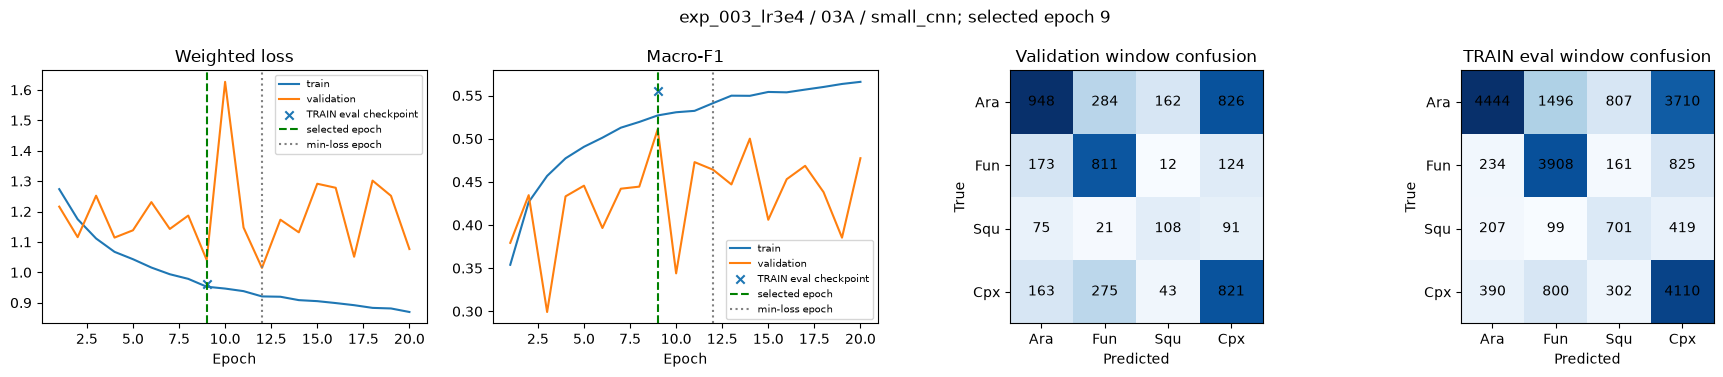

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.697572,0.427027,0.529757,2220.0
an funestus ss,0.583034,0.724107,0.645958,1120.0
an squamosus,0.332308,0.366102,0.348387,295.0
culex pipiens complex,0.440924,0.630568,0.518963,1302.0


accuracy                                                     0.615819
macro_precision                                              0.658133
macro_recall                                                 0.630691
macro_f1                                                     0.627887
weighted_f1                                                  0.615795
confusion_matrix    [[37, 4, 3, 33], [4, 29, 0, 4], [2, 0, 7, 4], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.74, 'recall'...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.171306
1,window,an arabiensis,LT,1753,0.495151
2,window,an funestus ss,HBN,46,0.326087
3,window,an funestus ss,LT,1074,0.741155
4,window,an squamosus,LT,295,0.366102
5,window,culex pipiens complex,HBN,523,0.795411
6,window,culex pipiens complex,LT,779,0.519897
7,source,an arabiensis,HBN,24,0.208333
8,source,an arabiensis,LT,53,0.603774
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,2.511419,0.029909,0.543327,3186.0
features.2.1,0.460758,0.097807,0.551542,3186.0
features.4.1,0.471388,0.056964,0.203612,3186.0


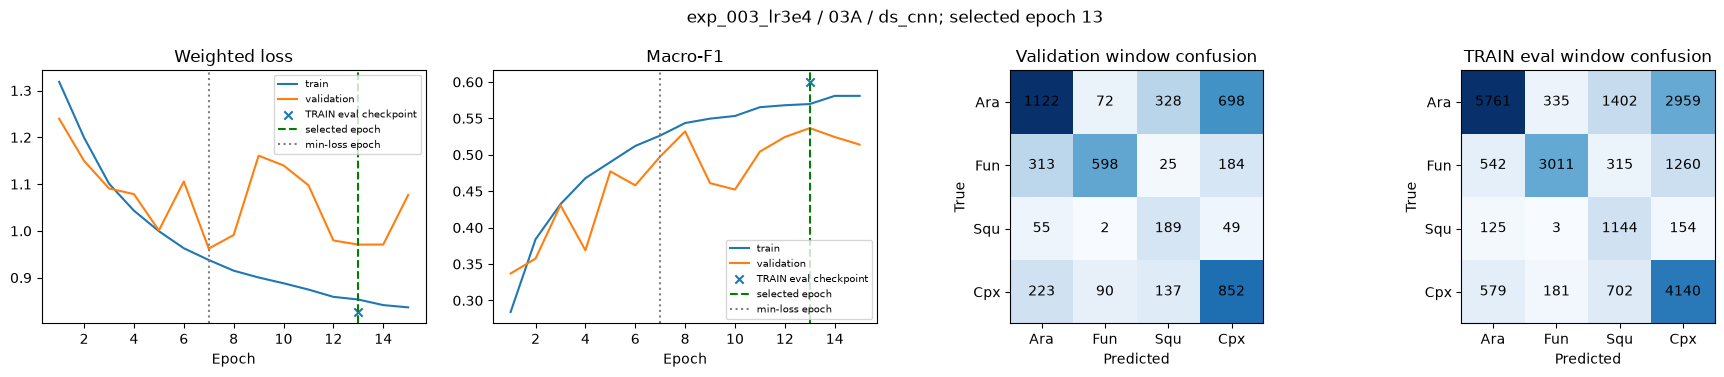

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.654991,0.505405,0.570557,2220.0
an funestus ss,0.784777,0.533929,0.635494,1120.0
an squamosus,0.278351,0.640678,0.388090,295.0
culex pipiens complex,0.477846,0.654378,0.552350,1302.0


accuracy                                                     0.638418
macro_precision                                              0.671036
macro_recall                                                 0.697081
macro_f1                                                     0.656509
weighted_f1                                                  0.642269
confusion_matrix    [[39, 0, 8, 30], [7, 25, 0, 5], [1, 0, 11, 1],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.709090909090...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.233405
1,window,an arabiensis,LT,1753,0.577867
2,window,an funestus ss,HBN,46,0.173913
3,window,an funestus ss,LT,1074,0.549348
4,window,an squamosus,LT,295,0.640678
5,window,culex pipiens complex,HBN,523,0.881453
6,window,culex pipiens complex,LT,779,0.501926
7,source,an arabiensis,HBN,24,0.250000
8,source,an arabiensis,LT,53,0.622642
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,2.941693,0.017453,0.678011,4602.0
features.1.1,0.167679,0.004399,0.616442,4602.0
features.2.1,0.163257,0.061630,0.455175,4602.0
features.3.1,0.178172,0.023426,0.375403,4602.0
features.4.1,0.239318,0.093031,0.250858,4602.0
features.5.1,0.294711,0.046920,0.389994,4602.0
features.6.1,0.171269,0.069758,0.411801,4602.0
features.7.1,0.313284,0.021337,0.661531,4602.0
features.8.1,0.151759,0.097103,0.257827,4602.0


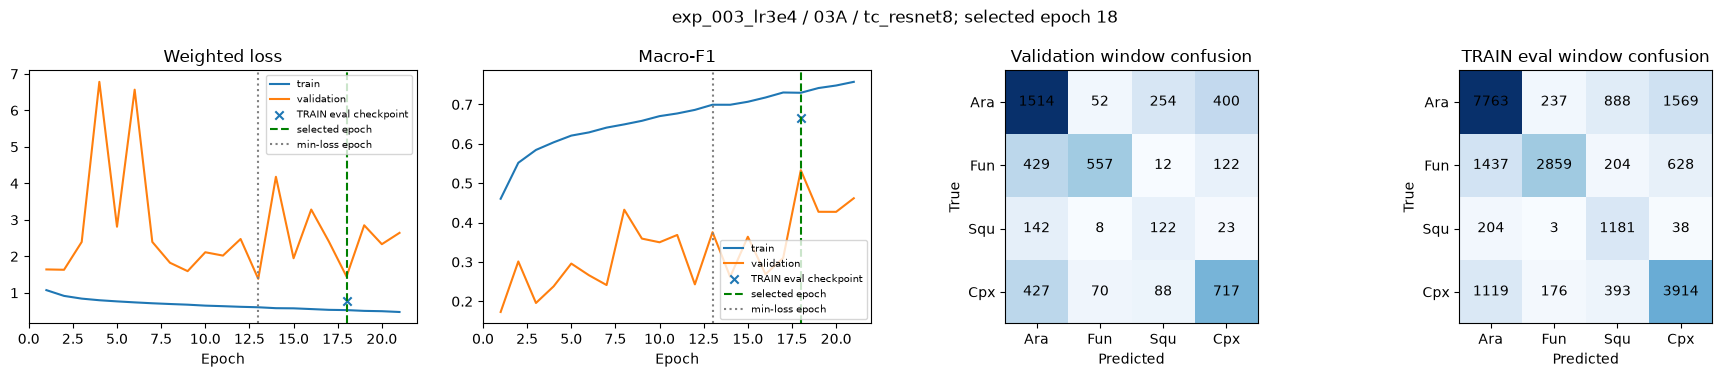

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.602707,0.681982,0.639899,2220.0
an funestus ss,0.810771,0.497321,0.616491,1120.0
an squamosus,0.256303,0.413559,0.316472,295.0
culex pipiens complex,0.568146,0.550691,0.559282,1302.0


accuracy                                                     0.666667
macro_precision                                              0.687887
macro_recall                                                 0.626572
macro_f1                                                     0.645923
weighted_f1                                                  0.667418
confusion_matrix    [[57, 1, 4, 15], [10, 21, 0, 6], [5, 0, 7, 1],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.655172413793...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.473233
1,window,an arabiensis,LT,1753,0.737593
2,window,an funestus ss,HBN,46,0.217391
3,window,an funestus ss,LT,1074,0.509311
4,window,an squamosus,LT,295,0.413559
5,window,culex pipiens complex,HBN,523,0.804971
6,window,culex pipiens complex,LT,779,0.379974
7,source,an arabiensis,HBN,24,0.541667
8,source,an arabiensis,LT,53,0.830189
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.1,2.460452,0.043789,0.291156,6372.0
features.3.main.1,0.288605,0.064863,0.268385,6372.0
features.3.main.4,0.267198,0.148816,0.447316,6372.0
features.3.skip.1,0.150609,0.046789,0.184481,6372.0
features.4.main.1,0.412313,0.239277,1.051234,6372.0
features.4.main.4,0.326259,0.168562,0.555751,6372.0
features.4.skip.1,0.293319,0.152585,0.776644,6372.0
features.5.main.1,0.507670,0.295113,1.659612,6372.0
features.5.main.4,0.306330,0.265715,0.854153,6372.0
features.5.skip.1,0.212588,0.148786,0.517535,6372.0


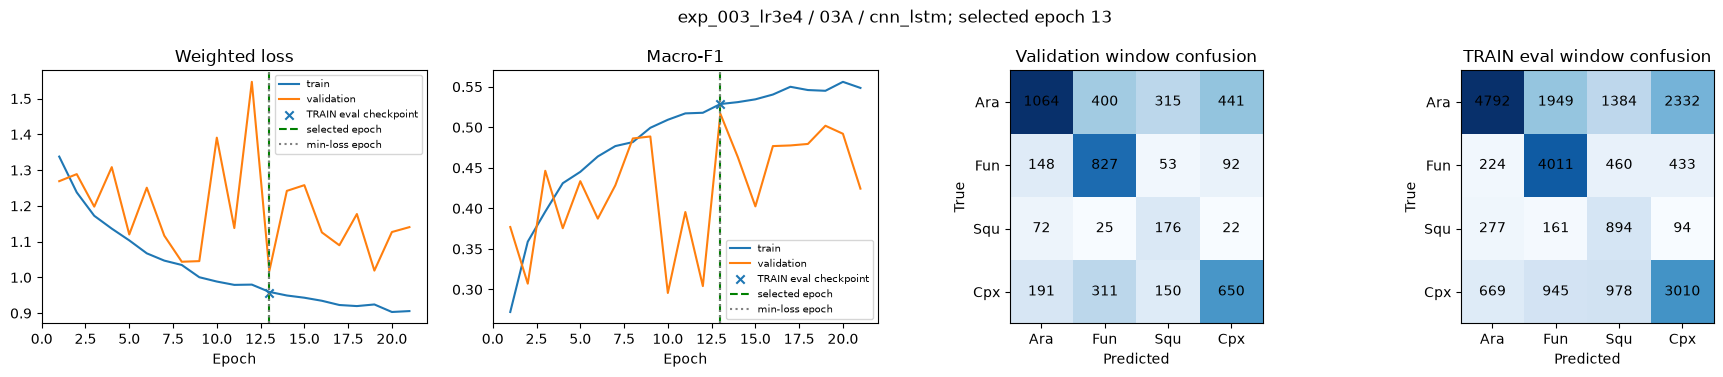

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.721356,0.479279,0.575913,2220.0
an funestus ss,0.529111,0.738393,0.616474,1120.0
an squamosus,0.253602,0.596610,0.355915,295.0
culex pipiens complex,0.539419,0.499232,0.518548,1302.0


accuracy                                                     0.615819
macro_precision                                              0.594556
macro_recall                                                 0.676894
macro_f1                                                     0.608096
weighted_f1                                                   0.61276
confusion_matrix    [[36, 9, 12, 20], [3, 30, 0, 4], [2, 1, 10, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.782608695652...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.049251
1,window,an arabiensis,LT,1753,0.593839
2,window,an funestus ss,HBN,46,0.239130
3,window,an funestus ss,LT,1074,0.759777
4,window,an squamosus,LT,295,0.596610
5,window,culex pipiens complex,HBN,523,0.858509
6,window,culex pipiens complex,LT,779,0.258023
7,source,an arabiensis,HBN,24,0.041667
8,source,an arabiensis,LT,53,0.660377
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,2.438643,0.022636,0.561068,4602.0
features.2.1,0.540262,0.103177,0.594129,4602.0


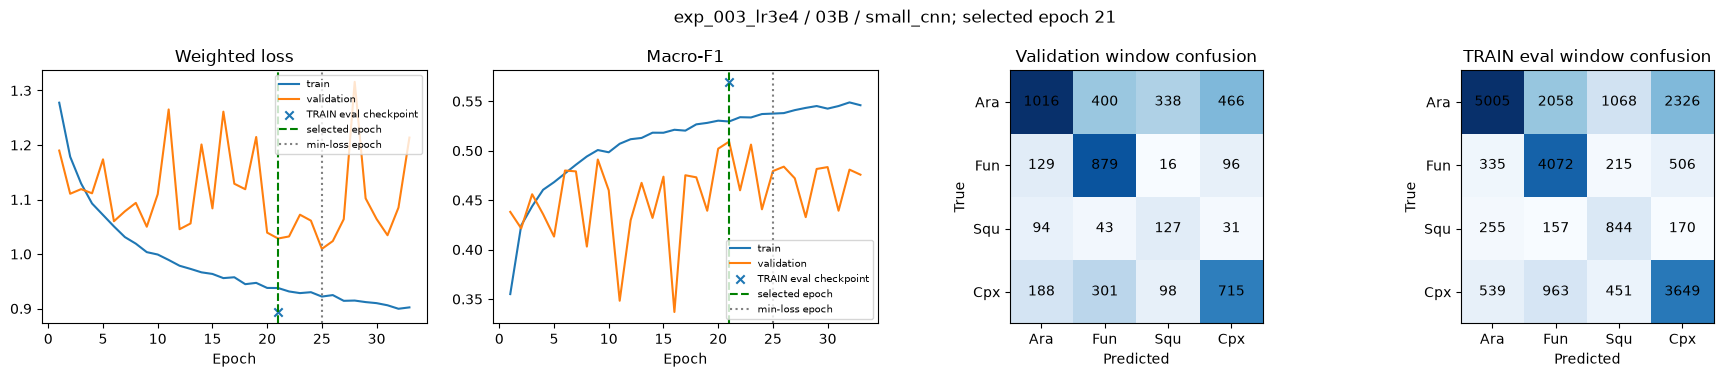

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.711983,0.457658,0.557170,2220.0
an funestus ss,0.541590,0.784821,0.640904,1120.0
an squamosus,0.219344,0.430508,0.290618,295.0
culex pipiens complex,0.546636,0.549155,0.547893,1302.0


accuracy                                                     0.610169
macro_precision                                              0.572338
macro_recall                                                 0.613217
macro_f1                                                     0.581681
weighted_f1                                                   0.60581
confusion_matrix    [[37, 9, 9, 22], [3, 30, 0, 4], [5, 1, 6, 1], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.711538461538...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.218415
1,window,an arabiensis,LT,1753,0.521392
2,window,an funestus ss,HBN,46,0.173913
3,window,an funestus ss,LT,1074,0.810987
4,window,an squamosus,LT,295,0.430508
5,window,culex pipiens complex,HBN,523,0.847036
6,window,culex pipiens complex,LT,779,0.349166
7,source,an arabiensis,HBN,24,0.208333
8,source,an arabiensis,LT,53,0.603774
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.009229,0.000095,0.002370,7434.0
features.2.1,0.627374,0.158537,1.240822,7434.0
features.4.1,0.450173,0.091464,0.283916,7434.0


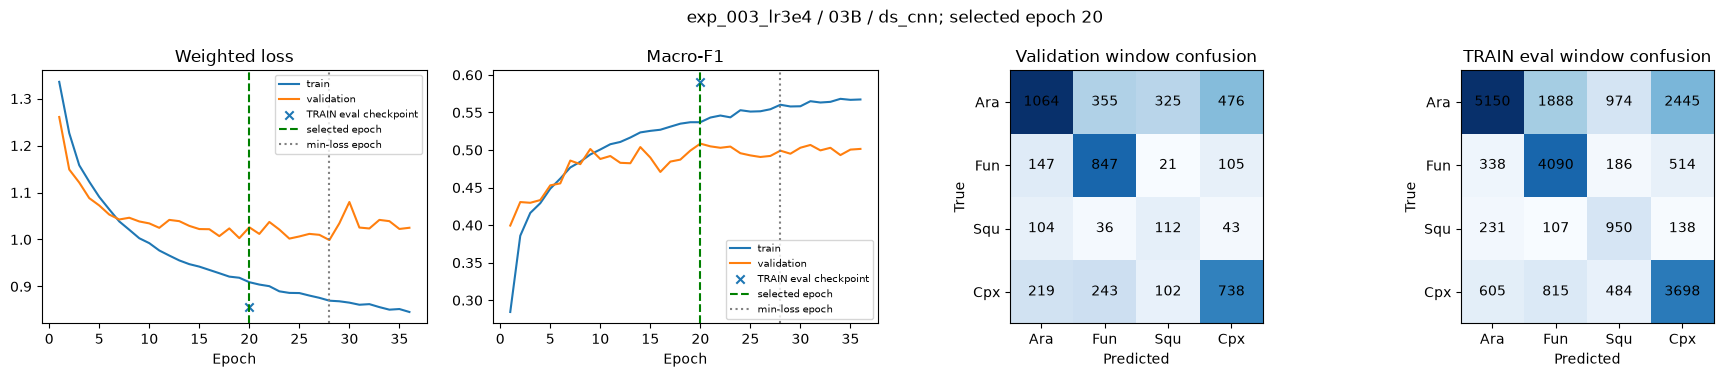

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.693611,0.479279,0.566862,2220.0
an funestus ss,0.571911,0.756250,0.651288,1120.0
an squamosus,0.200000,0.379661,0.261988,295.0
culex pipiens complex,0.541850,0.566820,0.554054,1302.0


accuracy                                                     0.644068
macro_precision                                              0.596199
macro_recall                                                 0.630941
macro_f1                                                      0.60644
weighted_f1                                                   0.64488
confusion_matrix    [[43, 6, 10, 18], [3, 29, 0, 5], [5, 1, 6, 1],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.741379310344...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.254818
1,window,an arabiensis,LT,1753,0.539076
2,window,an funestus ss,HBN,46,0.173913
3,window,an funestus ss,LT,1074,0.781192
4,window,an squamosus,LT,295,0.379661
5,window,culex pipiens complex,HBN,523,0.841300
6,window,culex pipiens complex,LT,779,0.382542
7,source,an arabiensis,HBN,24,0.333333
8,source,an arabiensis,LT,53,0.660377
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.011821,0.000095,0.004115,7080.0
features.1.1,0.140268,0.001926,0.759776,7080.0
features.2.1,0.144732,0.069879,0.362696,7080.0
features.3.1,0.135291,0.016016,0.634464,7080.0
features.4.1,0.212891,0.086729,0.336126,7080.0
features.5.1,0.271395,0.030566,0.440447,7080.0
features.6.1,0.155214,0.067537,0.304392,7080.0
features.7.1,0.335441,0.015303,0.853257,7080.0
features.8.1,0.210973,0.066854,0.238904,7080.0


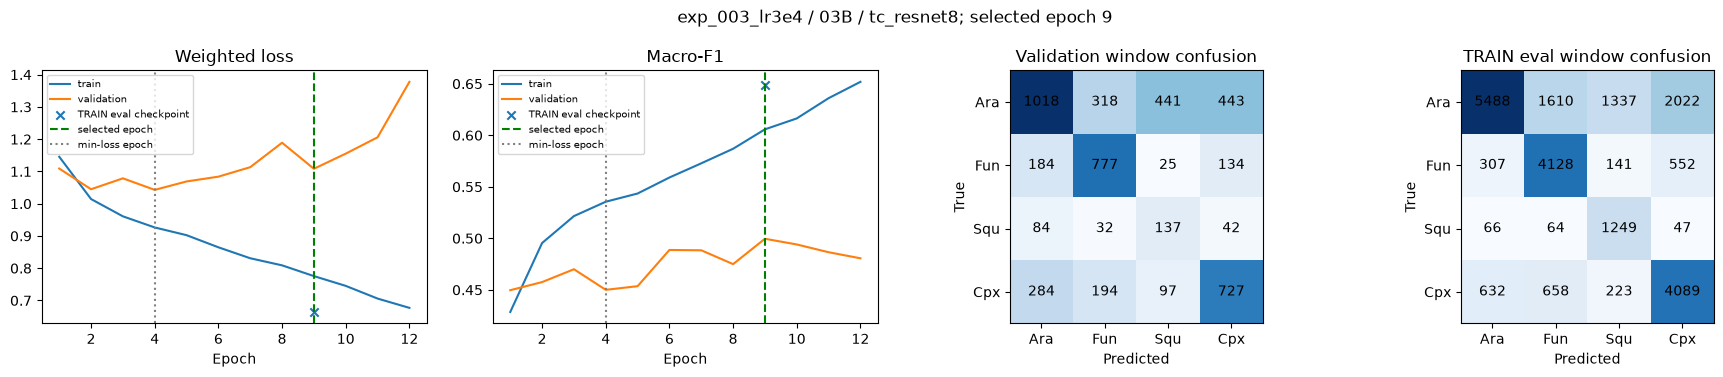

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.648408,0.458559,0.537203,2220.0
an funestus ss,0.588191,0.693750,0.636624,1120.0
an squamosus,0.195714,0.464407,0.275377,295.0
culex pipiens complex,0.540119,0.558372,0.549094,1302.0


accuracy                                                     0.666667
macro_precision                                              0.632325
macro_recall                                                 0.682912
macro_f1                                                     0.646041
weighted_f1                                                  0.666046
confusion_matrix    [[42, 6, 10, 19], [4, 30, 0, 3], [2, 1, 8, 2],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.763636363636...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.336188
1,window,an arabiensis,LT,1753,0.491158
2,window,an funestus ss,HBN,46,0.391304
3,window,an funestus ss,LT,1074,0.706704
4,window,an squamosus,LT,295,0.464407
5,window,culex pipiens complex,HBN,523,0.783939
6,window,culex pipiens complex,LT,779,0.406932
7,source,an arabiensis,HBN,24,0.375000
8,source,an arabiensis,LT,53,0.622642
9,source,an funestus ss,HBN,4,0.500000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.1,0.012841,0.000301,0.001968,3186.0
features.3.main.1,0.206483,0.057947,0.249132,3186.0
features.3.main.4,0.245087,0.100018,0.382108,3186.0
features.3.skip.1,0.136580,0.035934,0.181137,3186.0
features.4.main.1,0.398345,0.243290,1.064516,3186.0
features.4.main.4,0.274572,0.131384,0.439377,3186.0
features.4.skip.1,0.258380,0.095050,0.476102,3186.0
features.5.main.1,0.435010,0.211946,0.853868,3186.0
features.5.main.4,0.234064,0.209205,0.541469,3186.0
features.5.skip.1,0.248880,0.153507,0.388910,3186.0


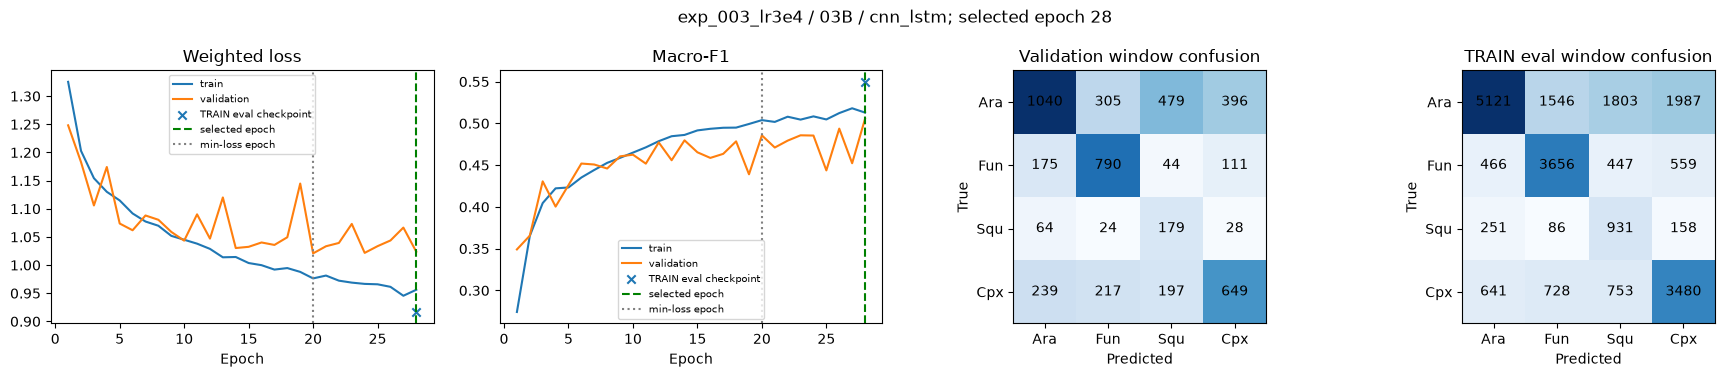

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.685112,0.468468,0.556447,2220.0
an funestus ss,0.591317,0.705357,0.643322,1120.0
an squamosus,0.199110,0.606780,0.299832,295.0
culex pipiens complex,0.548142,0.498464,0.522124,1302.0


accuracy                                                     0.627119
macro_precision                                              0.599588
macro_recall                                                 0.672857
macro_f1                                                     0.615632
weighted_f1                                                  0.630293
confusion_matrix    [[41, 5, 13, 18], [5, 27, 0, 5], [2, 1, 10, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.732142857142...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.321199
1,window,an arabiensis,LT,1753,0.507701
2,window,an funestus ss,HBN,46,0.108696
3,window,an funestus ss,LT,1074,0.730912
4,window,an squamosus,LT,295,0.606780
5,window,culex pipiens complex,HBN,523,0.804971
6,window,culex pipiens complex,LT,779,0.292683
7,source,an arabiensis,HBN,24,0.375000
8,source,an arabiensis,LT,53,0.603774
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.009951,0.000104,0.002933,9912.0
features.2.1,0.524461,0.144256,1.435173,9912.0


In [3]:
if all_complete:
    import matplotlib.pyplot as plt
    labels_short = ["Ara", "Fun", "Squ", "Cpx"]
    for frontend in BRANCHES:
        for family in FAMILIES:
            directory = RUNS / f"{frontend}_{family}_seed42"
            result = read_json(directory / "result.json")
            history = read_json(directory / "history.json")
            fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
            epochs = [h["epoch"] for h in history]
            for split in ("train", "validation"):
                axes[0].plot(epochs, [h[split]["loss"] for h in history], label=split)
                axes[1].plot(epochs, [h[split]["macro_f1"] for h in history], label=split)
            if "train_eval_metrics" in result:
                axes[0].scatter([result["best_epoch"]], [result["train_eval_metrics"]["loss"]], label="TRAIN eval checkpoint", marker="x")
                axes[1].scatter([result["best_epoch"]], [result["train_eval_metrics"]["macro_f1"]], label="TRAIN eval checkpoint", marker="x")
            for ax in axes[:2]:
                ax.axvline(result["best_epoch"], color="green", linestyle="--", label="selected epoch")
                if "checkpoint_candidates" in result:
                    ax.axvline(result["checkpoint_candidates"]["minimum_loss"]["epoch"], color="gray", linestyle=":", label="min-loss epoch")
                ax.legend(fontsize=7)
            axes[0].set(title="Weighted loss", xlabel="Epoch")
            axes[1].set(title="Macro-F1", xlabel="Epoch")
            secondary = result.get("final_test_metrics") or result.get("train_eval_metrics")
            secondary_title = "TEST" if result.get("final_test_metrics") else "TRAIN eval"
            for ax, metrics, title in ((axes[2], result["selected_validation_metrics"], "Validation"),
                                       (axes[3], secondary, secondary_title)):
                if metrics is None:
                    ax.set_visible(False)
                    continue
                cm = metrics["confusion_matrix"]
                ax.imshow(cm, cmap="Blues")
                for i in range(4):
                    for j in range(4):
                        ax.text(j, i, cm[i][j], ha="center", va="center")
                ax.set(title=title + " window confusion", xlabel="Predicted", ylabel="True",
                       xticks=range(4), yticks=range(4), xticklabels=labels_short, yticklabels=labels_short)
            fig.suptitle(f"{EXPERIMENT_NAME or 'fixed baseline'} / {frontend} / {family}; selected epoch {result['best_epoch']}")
            fig.tight_layout(); plt.show()
            print("Validation per-class:")
            display(pd.DataFrame(result["selected_validation_metrics"]["per_class"]).T)
            if "validation_source_metrics" in result:
                display(pd.Series(result["validation_source_metrics"], name="Validation source evaluation"))
            if result.get("final_test_metrics") is not None:
                print("TEST per-class (descriptive, not for tuning):")
                display(pd.DataFrame(result["final_test_metrics"]["per_class"]).T)
                display(pd.Series(result["source_test_metrics"], name="TEST source evaluation"))
            else:
                print("TEST chưa được đánh giá trong experiment này; dùng validation để tuning.")
            if (directory / "diagnostics.json").is_file():
                diagnostics = read_json(directory / "diagnostics.json")
                print("Validation species × acquisition method (support + recall):")
                display(pd.DataFrame(diagnostics["validation_subgroups"]))
                print("BatchNorm running statistics tại checkpoint được chọn:")
                display(pd.DataFrame(diagnostics["batchnorm_selected_checkpoint"]).T)


## So sánh validation với experiment đối chứng

Đọc reference từ config đã lưu, hoặc nhập tên khác ở cell dưới.
So sánh ghép cặp cùng model/frontend; không dùng TEST để chọn cấu hình.
Kiểm tra cột Same runtime và criterion trước khi diễn giải chênh lệch.


In [4]:
REFERENCE_EXPERIMENT_NAME = ""  # Để trống: dùng reference_experiment_id đã lưu trong config.
if all_complete and EXPERIMENT_NAME:
    from experiment_review import compare_validation_to_reference
    reference_name = REFERENCE_EXPERIMENT_NAME or metadata["configuration"].get("reference_experiment_id")
    if reference_name:
        reference_path = PATHS.experiment(reference_name)
        if (reference_path / "config/metadata.json").is_file():
            display(compare_validation_to_reference(EXPERIMENT_NAME, reference_name))
        else:
            print("Chưa tìm thấy reference:", reference_path, "; kết quả hiện tại vẫn được xác thực riêng.")
    else:
        print("Experiment cũ không có reference; nhập REFERENCE_EXPERIMENT_NAME nếu muốn so sánh.")


,Run,Reference,Experiment,Reference val Macro-F1,Current val Macro-F1,Delta val F1 (percentage points),Reference selected epoch,Current selected epoch,Same runtime,Reference criterion,Current criterion
0,03A_small_cnn_seed42,exp_002_control_v2,exp_003_lr3e4,0.503374,0.510766,0.739197,9,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1
1,03A_ds_cnn_seed42,exp_002_control_v2,exp_003_lr3e4,0.541043,0.536623,-0.441986,8,13,True,maximum_validation_macro_f1,maximum_validation_macro_f1
2,03A_tc_resnet8_seed42,exp_002_control_v2,exp_003_lr3e4,0.406385,0.533036,12.665161,1,18,True,maximum_validation_macro_f1,maximum_validation_macro_f1
3,03A_cnn_lstm_seed42,exp_002_control_v2,exp_003_lr3e4,0.548213,0.516713,-3.150019,28,13,True,maximum_validation_macro_f1,maximum_validation_macro_f1
4,03B_small_cnn_seed42,exp_002_control_v2,exp_003_lr3e4,0.481530,0.509146,2.761608,7,21,True,maximum_validation_macro_f1,maximum_validation_macro_f1
5,03B_ds_cnn_seed42,exp_002_control_v2,exp_003_lr3e4,0.513811,0.508548,-0.526253,9,20,True,maximum_validation_macro_f1,maximum_validation_macro_f1
6,03B_tc_resnet8_seed42,exp_002_control_v2,exp_003_lr3e4,0.521638,0.499575,-2.206399,15,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1
7,03B_cnn_lstm_seed42,exp_002_control_v2,exp_003_lr3e4,0.488767,0.505432,1.666456,12,28,True,maximum_validation_macro_f1,maximum_validation_macro_f1


## Limits before Stage 05

No Edge winner is declared. Float32 checkpoint size is not INT8 size, RAM, Flash or latency.
This one-seed comparison makes no claims of superiority to published literature. Multiple windows may
share one recording; source-name isolation does not prove biological/session/domain independence.
The frozen acquisition-method confounding remains. Read [Stage 04 methodology](../../docs/STAGE04.md).
